# EX2: Alpha Particle Range in Air

## Session 1: Feb 3rd, 2026

#### 1.1 Goals for this session
- Read through alpha lab manuals v2023 and v2022 for theory
- Get acquainted with the apparatus and Python scripts
- Take some simple pressure readings  

#### 1.2 Purpose of this lab
- Study energy loss of charged alpha particles in matter (air)
- Find function that describes energy loss as a function of particle energy

#### 1.3 Some background theory
- Charged particles lose energy as they pass through a medium by ionizing atoms in their path
- Particles stop moving when all energy is lost
- The rate of energy loss of alpha particles can be modelled by the Bethe-Bloch equation: 
$$-\frac{dE}{dx} = \frac{4\pi Z^2}{m_e v^2} \left( \frac{e^2}{4\pi\epsilon_0} \right)^2 n_e \ln \frac{2m_e v^2}{I}$$

- Solid state pressure transducer -> converts pressure into voltage readings 
- OOH one really cool use case of this is figuring out the placement of smoke detectors from household hotspots (eg. kitchen, fireplace, etc) 
- Bragg curve = plots energy loss from ioninization as a function of travel through matter
- Oh wow, Bragg curves used lots in medical applications
    - For example, to target a tumor by tuning incident energy to go a speciifc depth (avoid good tissue around it)


#### 1.4 Experiment apparatus
- This is what the experiment apparatus looks like:

    <img src="../assets/setup.png" height="300" alt="setup"/>

- After 5 mins of wondeirng why the pump wasn't making any noise, I realized I completely forget to switch on the main power 
- Make sure to read the instructions on the control module panel 

  <img src="../assets/control_module.jpg" width="400" alt="control module panel">
  
- Need to turn on 5V main power and then the 12VDC power supply
- The relay board gives power to solenoid values (controls vacuum), the pressure transducer, and the relay board (control signals)
- These are some next helpful Python commands:
    - `python3 src/ControlVacuumV2.py --help` for list of supported functions
    - `python3 src/ControlVacuumV2.py --pump True` to turn pump ON (run at beginning of experiment)
    - `python3 src/ControlVacuumV2.py --pump False` to turn pump OFF (make sure to run before leaving)
    - `python3 src/ControlVacuumV2.py --status` to check status of vacuum and room valve
    - `python3 src/ControlVacuumV2.py --vacuumvalve 120` to pump air out of chamber for 120 seconds (increase time as neccessary to create desired vacuum)
    - `python3 src/ReadPressure.py` to read pressure as voltage readings 


#### 1.5 Pressure calibration

- `ReadMM.py` reads ~$8.7$ V when I open the room valve for 10s and let the chamber pressure fill up with air so that is $P = 1$ atm, gauge needle points to atm
    ```
    evinli@p400-54:~/Dev/evin-li-EX2-alpha $ python3 src/ReadPressure.py
    Will open instrument USB0::6833::1303::DS1ZE232913033::0::INSTR
    VAVG = 3.960067e+00 V
    VAVG = 3.895251e+00 V
    VAVG = 3.896187e+00 V
    VAVG = 3.873043e+00 V
    VAVG = 3.886153e+00 V
    VAVG = 3.800422e+00 V
    VAVG = 3.798395e+00 V

- After vacuum pumping for $5$ mins, the pressure gauge now reads around $220$ mT - we'll define this as our "vacuum" since the pump can't go any lower (device limitation)
    ```
    evinli@p400-54:~/Dev/evin-li-EX2-alpha $ python3 src/ReadPressure.py
    Will open instrument USB0::6833::1303::DS1ZE232913033::0::INSTR
    VAVG = 9.128378e+00 V
    VAVG = 9.137291e+00 V
    VAVG = 9.133110e+00 V
    VAVG = 9.143228e+00 V
    VAVG = 9.140285e+00 V
    VAVG = 9.130986e+00 V
    VAVG = 9.132508e+00 V
    VAVG = 9.126103e+00 V
    ```

- To figure out the precise atmospheric pressure, I used Fortin barometer mounted against the back corner wall 
    - Make sure bottom edge of vernier cursor is level with the Mercury meniscus 
    - First 2 significant digit are read on outer brass scale
    - Last digit is read from the pair of lines that most closely match up on the vernier + outer scale
    - I'm reading `~764.3` Torr as atmospheric pressure

        <img src="../assets/fortin.png" width="400" alt="Fortin barometer anatomy">

- We can use linear interpolation to figure out the relationship between chamber pressure and the transducer response
- We have 2 known points:
    - $764.3$ Torr = $3.331 \pm 0.005$ V
    - $0.220$ Torr = $9.134 \pm 0.003$ V

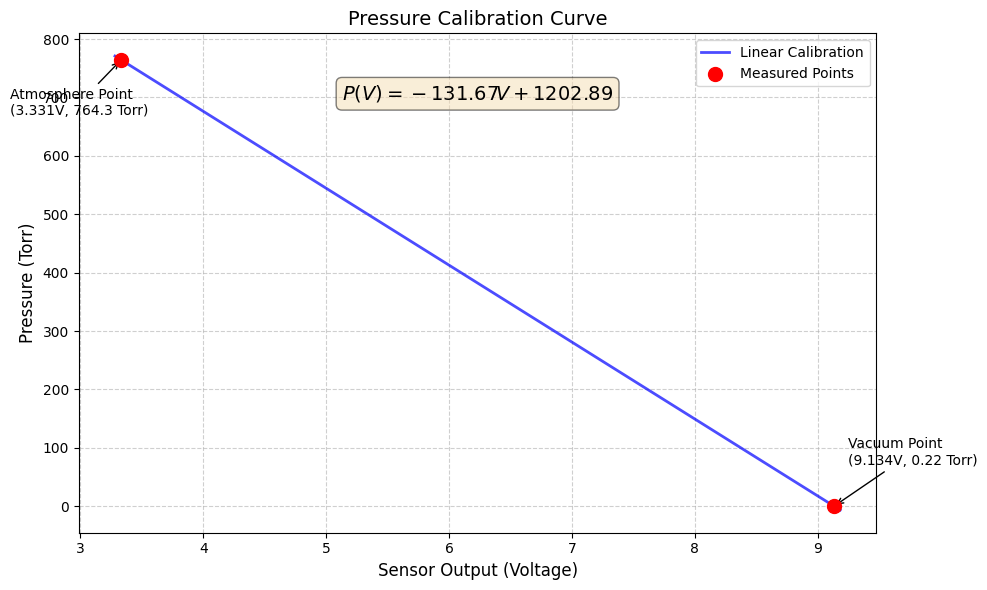

Figure 1: Pressure calibration curve for transducer


In [2]:
import numpy as np
import matplotlib.pyplot as plt

v_vac = 9.134
p_vac = 0.220
v_atm = 3.331
p_atm = 764.3

m = (p_atm - p_vac) / (v_atm - v_vac)
b = p_vac - m * v_vac

v_vals = np.linspace(v_atm - 0.05, v_vac + 0.05, 100)
p_vals = m * v_vals + b

plt.figure(figsize=(10, 6))
plt.plot(v_vals, p_vals, 'b-', label='Linear Calibration', linewidth=2, alpha=0.7)
plt.scatter([v_vac, v_atm], [p_vac, p_atm], color='red', s=100, zorder=5, label='Measured Points')

# Best ways to annotate matplotlib plot
plt.annotate(f'Vacuum Point\n({v_vac}V, {p_vac} Torr)', 
             xy=(v_vac, p_vac), xytext=(10, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate(f'Atmosphere Point\n({v_atm}V, {p_atm} Torr)', 
             xy=(v_atm, p_atm), xytext=(-80, -40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))
equation_text = f'$P(V) = {m:.2f}V + {b:.2f}$'
plt.gca().text(0.5, 0.9, equation_text, transform=plt.gca().transAxes, 
               fontsize=14, verticalalignment='top', horizontalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title('Pressure Calibration Curve', fontsize=14)
plt.xlabel('Sensor Output (Voltage)', fontsize=12)
plt.ylabel('Pressure (Torr)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Figure 1: Pressure calibration curve for transducer")

In [3]:
def voltage_to_pressure(voltage):
    """
    Function to convert transducer voltage to pressure, useful for future data analysis
    """
    return -131.67 * voltage + 1202.89 # in Torr

## Session 2: Feb 12th, 2026

- Okay need to figure out what kind of traces to collect today
- Forgot to write this down last time, but open the SSH connection like this: `ssh evinli@p400-54.phas.ubc.ca` 
- OH VPN wasn't connecting for the longest time, realized my phone had offloaded Duo so I didn't get the push notification (verification method chosen by `@app` or `@call`)
- And then for scp-ing files over to PI: `scp ~/Dev/enph_352/evin-li-EX2-alpha/src/ReadPressure.py evinli@p400-54.phas.ubc.ca:~/Dev/evin-li-EX2-alpha/src`

#### 2.1 Today's goals
- Grab a single $\alpha$ particle detection trace from the oscilloscope 
- Write script for automated data collection; this dataset should include the pulse arrival rate (num of triggers) and peak-to-peak $\alpha$ particle voltage as a function of DMM pressure readings

#### 2.2 Grab single $\alpha$ particle trace

- Lab manual recommends doing this as a sanity check that oscilloscope is able to trigger on $\alpha$ particles
- First thing I did is open the vacuum valve and pump out the system to about $200$ mT
- Should be comparing the scope trace with Figure 6. in the 2022 lab manual
- Used this command to get the scope trace: `python3 src/ScopeTraceCapture.py --triggerLevel 0 --triggerChannel CHAN1 --outputFile today`
- This saved voltage and time arrays as `.dat` files which I used `cat` to print in terminal and copied them over to my own laptop as a `.csv` file
- Tip: ^Use Vim in visual mode and ctrl-V, shift-A to paste a 2nd column in a multi-line batch
- Visualizing this data, we see that it matches the plot from the manual


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

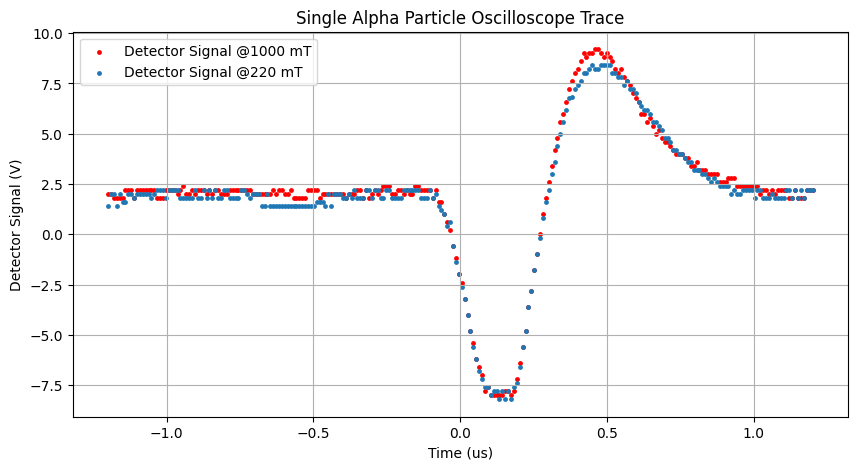

Figure 2: Oscilloscope trace of single alpha particle


In [5]:
no_vac_df = pd.read_csv('../data/2026-01-20_13_20_53_scope_trace_1000_mT.csv')
low_vac_df = pd.read_csv('../data/2026-01-20_13_52_23_scope_trace_220_mT.csv')

plt.figure(figsize=(10, 5))
plt.title('Single Alpha Particle Oscilloscope Trace')
plt.scatter(no_vac_df['Time (s)'] * 1e5, no_vac_df['Voltage (V)'], label='Detector Signal @1000 mT', s=6, color='red')
plt.scatter(low_vac_df['Time (s)'] * 1e5, low_vac_df['Voltage (V)'], label='Detector Signal @220 mT', s=6)
plt.xlabel('Time (us)')
plt.legend()
plt.grid()
plt.ylabel('Detector Signal (V)')
plt.show()

print("Figure 2: Oscilloscope trace of single alpha particle")

Hmm, one observation is that the amplitude of my shape is a lot larger than the example trace. They have a peak-to-peak voltage of ~4V but mine is closer to 17V... If all other conditions are similar (pressure, temperature), I'm a little confused why my height would be higher. Could this be because my radioactive Americium source is newer? And all the $\alpha$ particles inside have higher avg. energy? Would like to deep dive into this a bit more next week

Also not entirely convinced that the amplitude of this signal doesn't change with pressure... UPDATE: the amplitude did end up changing, I just had to open the room valve and let the pressure go beyond atmospheric pressure

#### 2.3 Automating data collection script
- Making a new Python script called `src/RunDataCollection.py`
- The purpose of this is to create a singular hands-free automatic way of collecting our datasets
- In this script, I've added an event callback that triggers on rising edge of GPIO pin 5 so that we can monitor number of alpha particles
- Also adding in a pipeline that regularly turns on the pump and lowers the tank pressure so that we can collect peak-to-peak voltages (on CHAN1) for different pressure points (monitored by DMM on CHAN2)



## Session 3: Feb 24, 2026

#### 3.1 Today's goals
- Finish writing the automated data collection scripts from last week
- Collect data using these scripts^
- Do some live-plotting to validate the datasets before post-lab analysis begins

#### 3.2 Data collection 
 - Testing two scripts today:
    - One for collecting histogram of peak voltages at 2 separate pressure points: `scp ~/Dev/enph_352/evin-li-EX2-alpha/src/RunVppCollection.py evinli@p400-54.phas.ubc.ca:~/Dev/evin-li-EX2-alpha/src`
    - And another for the full data collection of a Bragg's curve: `scp ~/Dev/enph_352/evin-li-EX2-alpha/src/RunDataCollection.py evinli@p400-54.phas.ubc.ca:~/Dev/evin-li-EX2-alpha/src`
   
- Trigger count histogram was collectd at around $200$ mT and atmospheric pressure
- For the one where we continously let air into the chamber... can this cause an explosion from pressure buildup??? 
    - The pressure gauge we have doesn't have a lot of granularity beyond 2000 mT so "atmo" pressure could really mean anything
    - Realized that this might also poorly affect the calibration process we did at the beginning 

- Remembering that the main purpose of the experiment is to generate a Bragg curve for $\alpha$ partilces in an air column... trying to think if there's any other data I should be collecting 
- In the meantime, let's plot a few of the datasets I collected today - repeated the experiment on as large of a pressure range as possible in hopes we have enough data to visualize the full Bragg's curve 


#### 3.3 Plotting $\alpha$ particle energy distribution

- To see what the energy distribution looks like at vacuum vs. at atmospheric pressure, I collected the following two datasets
- I'm expecting that the histogram at $P_{atm}$ will be near zero since there is a large air column that causes large energy loss

Mean Vpp @P_vac: 16.67 V
Standard deviation of Vpp @P_vac: 1.09 V
Mean Vpp @P_atm: 0.63 V
Standard deviation of Vpp @P_atm: 0.45 V


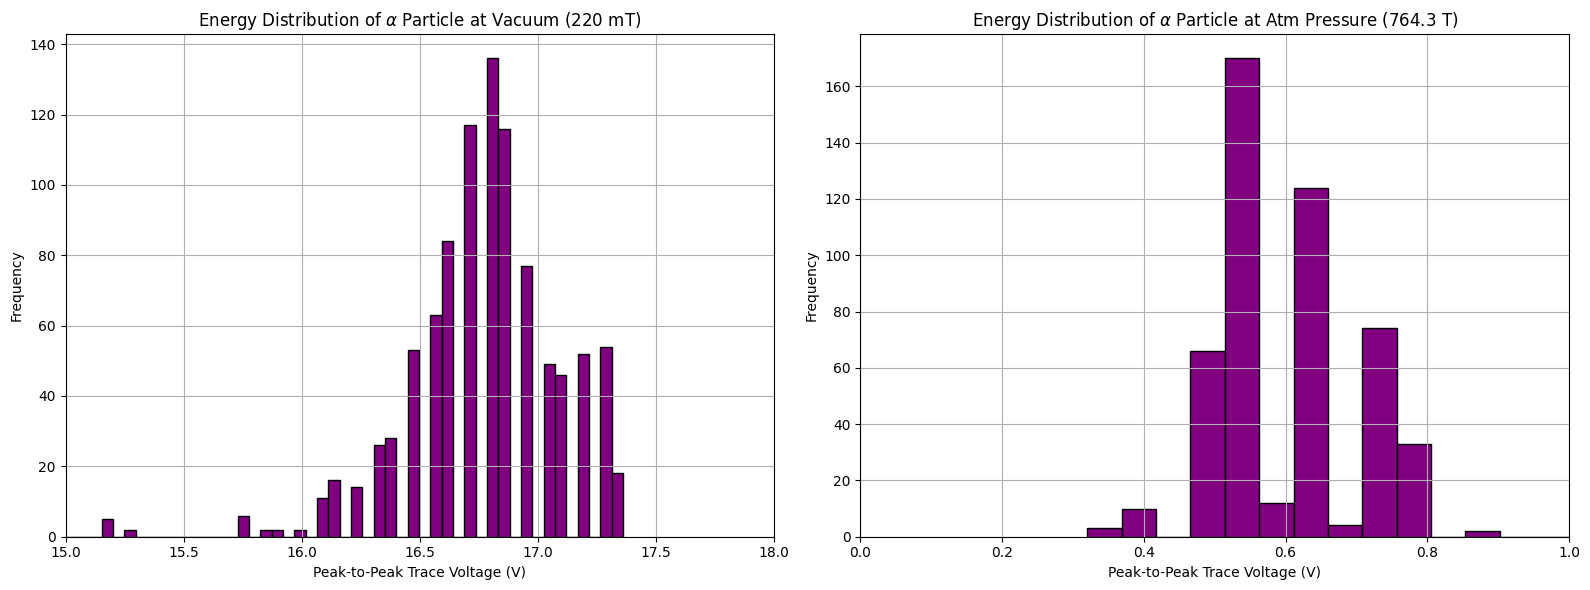

Figure 3: Histogram of alpha particle energy distribution at two different pressures


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
file_vac = '../data/2026-02-24_12_55_18_particle_vpp_at_200_mT.csv'
file_atm = '../data/2026-02-24_12_45_26_particle_vpp_at_atm.csv'
df_vac = pd.read_csv(file_vac)
df_atm = pd.read_csv(file_atm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_vac['Peak-to-Peak Voltage (Vpp)'].dropna(), bins=350, color='purple', edgecolor='black')
axes[0].set_title(rf'Energy Distribution of $\alpha$ Particle at Vacuum (220 mT)')
axes[0].set_xlabel('Peak-to-Peak Trace Voltage (V)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(15, 18)
axes[0].grid(True)

mean_p2p = np.mean(df_vac['Peak-to-Peak Voltage (Vpp)'])
std_p2p = np.std(df_vac['Peak-to-Peak Voltage (Vpp)'])
print(f"Mean Vpp @P_vac: {mean_p2p:.2f} V")
print(f"Standard deviation of Vpp @P_vac: {std_p2p:.2f} V")

axes[1].hist(df_atm['Peak-to-Peak Voltage (Vpp)'].dropna(), bins=150, color='purple', edgecolor='black')
axes[1].set_title(rf'Energy Distribution of $\alpha$ Particle at Atm Pressure (764.3 T)')
axes[1].set_xlabel('Peak-to-Peak Trace Voltage (V)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1)
axes[1].grid(True)

mean_p2p = np.mean(df_atm['Peak-to-Peak Voltage (Vpp)'])
std_p2p = np.std(df_atm['Peak-to-Peak Voltage (Vpp)'])
print(f"Mean Vpp @P_atm: {mean_p2p:.2f} V")
print(f"Standard deviation of Vpp @P_atm: {std_p2p:.2f} V")

plt.tight_layout()
plt.show()

print('Figure 3: Histogram of alpha particle energy distribution at two different pressures')

- Hmm I wish I let the data collection script run a little longer in the atmospheric pressure case so we can see the full distribution come into effect
- But even with the slightly limited data here, we can clearly see how the energy distribution has shifted to the left towards $0$ V as the chamber pressure increases (more air is let in)
    - This aligns with the results of out pre-lab exercise 

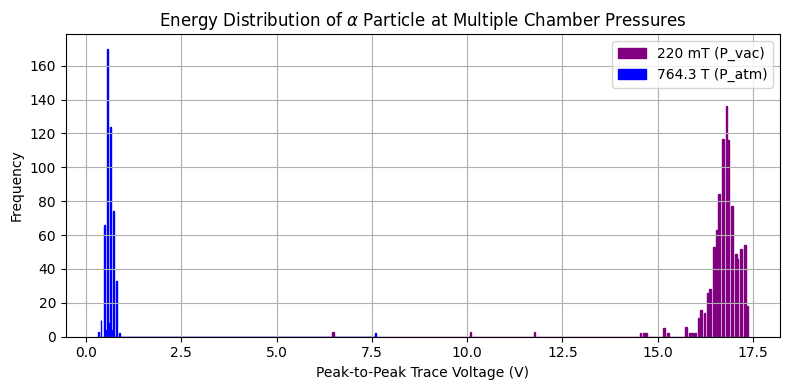

Figure 4: Plot overlaying energy distribution histograms from two different chamber pressures


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_vac = '../data/2026-02-24_12_55_18_particle_vpp_at_200_mT.csv'
file_atm = '../data/2026-02-24_12_45_26_particle_vpp_at_atm.csv'
df_vac = pd.read_csv(file_vac)
df_atm = pd.read_csv(file_atm)

plt.figure(figsize=(8,4))
plt.hist(df_vac['Peak-to-Peak Voltage (Vpp)'].dropna(), bins=350, color='purple', edgecolor='purple', label='220 mT (P_vac)')
plt.hist(df_atm['Peak-to-Peak Voltage (Vpp)'].dropna(), bins=350, color='blue', edgecolor='blue', label='764.3 T (P_atm)')
plt.title(rf'Energy Distribution of $\alpha$ Particle at Multiple Chamber Pressures')
plt.xlabel('Peak-to-Peak Trace Voltage (V)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('Figure 4: Plot overlaying energy distribution histograms from two different chamber pressures')

#### 3.4 Visualizing Vpp vs chamber pressure

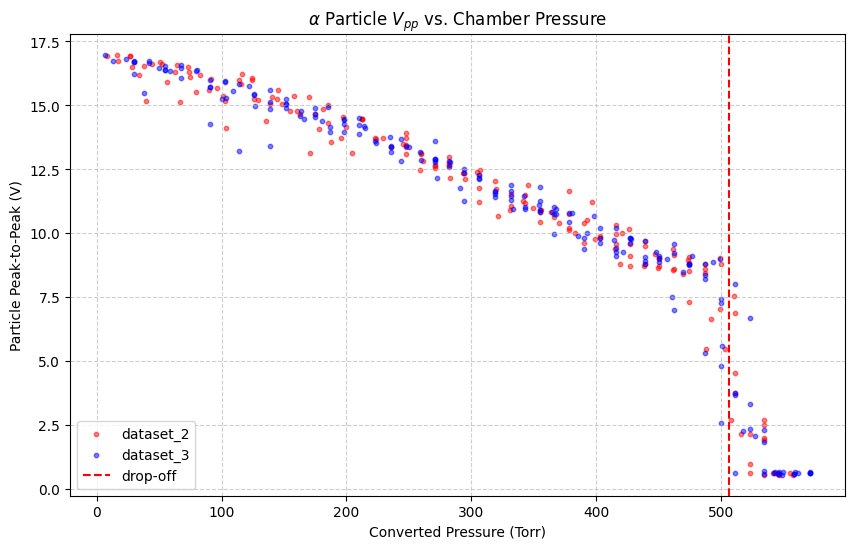

Figure 5: Peak-to-peak particle voltage as a function of chamber pressure


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_2 = '../data/2026-02-24_13_47_13_trig_and_vpp_vs_pressure2.csv'
dataset_3 = '../data/2026-02-24_14_05_56_trig_and_vpp_vs_pressure3.csv'
df_2 = pd.read_csv(dataset_2)
df_3 = pd.read_csv(dataset_3)

# Convert transducer voltage to pressure values
pressure_3 = voltage_to_pressure(df_3["Pressure DMM (V_avg)"]) 
pressure_2 = voltage_to_pressure(df_2["Pressure DMM (V_avg)"]) 

plt.figure(figsize=(10, 6))
plt.scatter(pressure_2, 
            df_2["Particle Peak-to-Peak (Vpp)"], 
            alpha=0.5, 
            s=10, 
            color='red', label='dataset_2')
plt.scatter(pressure_3, 
            df_3["Particle Peak-to-Peak (Vpp)"], 
            alpha=0.5, 
            s=10, 
            color='blue', label='dataset_3')
plt.axvline(506, color='red', linestyle='--', label='drop-off')

plt.title(r'$\alpha$ Particle $V_{pp}$ vs. Chamber Pressure')
plt.xlabel('Converted Pressure (Torr)')
plt.ylabel('Particle Peak-to-Peak (V)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print("Figure 5: Peak-to-peak particle voltage as a function of chamber pressure")

- Hmmm, I am very skeptical about the calibration curve I created from the first week
- Since the pressure gauge reads "atm" for a large range of pressures, basically for anything beyond $2000$ mT, I have a feeling that I didn't get the correct DMM reading for $P = 1$ atm
- This will significantly affect the rest of the data analysis... let me see what I can do...
- For now, I will be referring to the chamber pressure I calculate from the DMM readings as "converted pressure" - to indicate that they may not be the true chamber pressure 

- On the other hand, this peak-to-peak voltage looks pretty correct for both dataset 2 and 3
- By the end of the dataset, I recall seeing no more alpha particle traces on the oscilloscope which we also see reflected in the Vpp

#### 3.5 Visualizing trigger count vs chamber pressure

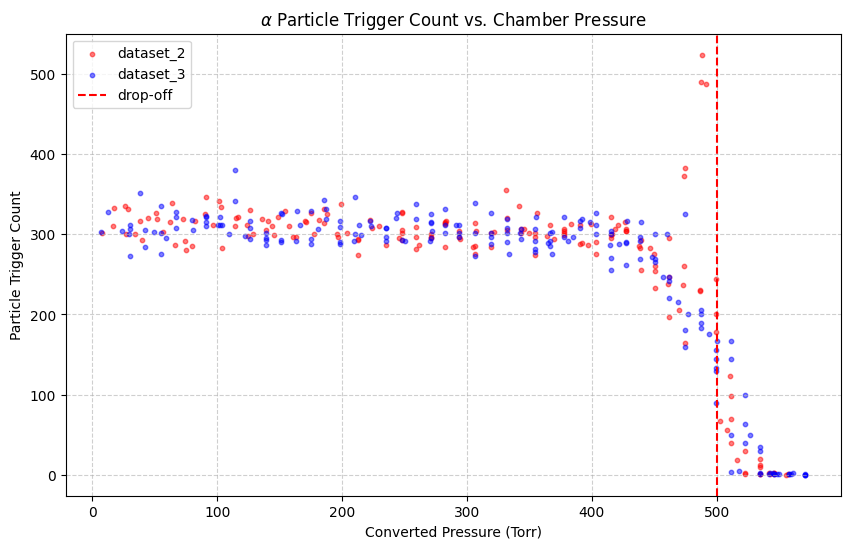

Figure 6: Alpha particle trigger count as a function of chamber pressure


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_2 = '../data/2026-02-24_13_47_13_trig_and_vpp_vs_pressure2.csv'
dataset_3 = '../data/2026-02-24_14_05_56_trig_and_vpp_vs_pressure3.csv'
df_2 = pd.read_csv(dataset_2)
df_3 = pd.read_csv(dataset_3)

# Convert transducer voltage to pressure values
pressure_3 = voltage_to_pressure(df_3["Pressure DMM (V_avg)"]) 
pressure_2 = voltage_to_pressure(df_2["Pressure DMM (V_avg)"]) 

plt.figure(figsize=(10, 6))
plt.scatter(pressure_2, 
            df_2["Trigger Count"], 
            alpha=0.5, 
            s=10, 
            color='red', label='dataset_2')
plt.scatter(pressure_3, 
            df_3["Trigger Count"], 
            alpha=0.5, 
            s=10, 
            color='blue', label='dataset_3')
plt.axvline(500, color='red', linestyle='--', label='drop-off')
plt.title(r'$\alpha$ Particle Trigger Count vs. Chamber Pressure')
plt.xlabel('Converted Pressure (Torr)')
plt.ylabel('Particle Trigger Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print("Figure 6: Alpha particle trigger count as a function of chamber pressure")

- This looks fairly similarly to what I initially expected
- We stop seeing alpha particles trigger (or see a lot less) as the chamber pressure increases
- At atmospheric pressure, the pulse arrival rate is roughly 0, and the count plummets to 0 as well

## Post-Lab: Mar 8th, 2026

#### 4.1 Today's goals
- Generate a Bragg's curve with dataset 2 and 3 from last week
- Ignore dataset 1, it contains too many clipped/out-of-bounds values for the DMM channel - fixed for dataset 2 and 3 by increasing volts/div

#### 4.2 Plotting particle energy w.r.t effective distance
- Since the Bragg's curve is a graph with $-dE/dx$ and the y-axis and effective distance ($x$) on the x-axis, I'll need to figure out a way to convert the peak-to-peak particle voltage to energy (MeV) and chamber pressure to effective distance

- Hmm to get the total energy deposited in the detector, we could just do $V_{pp} \times$ trigger count
- According to the manual, this seems like it better represents the total "ionizing power" delivered at given pressure point rather than the individual energy of just one particle 
- Based on page 5 of the 2022 manual, the effective distance between the source and the detector is given by:

$$d = \frac{P}{P_{atm}}d_o \text{  where  } d_o = 4.5 \text{ cm}$$


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_2 = '../data/2026-02-24_13_47_13_trig_and_vpp_vs_pressure2.csv'
dataset_3 = '../data/2026-02-24_14_05_56_trig_and_vpp_vs_pressure3.csv'
df_2 = pd.read_csv(dataset_2)
df_3 = pd.read_csv(dataset_3)

# Convert transducer voltage to pressure values
pressure_2 = voltage_to_pressure(df_2["Pressure DMM (V_avg)"]) 
pressure_3 = voltage_to_pressure(df_3["Pressure DMM (V_avg)"]) 

In [23]:
base_energy_2 = (df_3["Particle Peak-to-Peak (Vpp)"] * df_3["Trigger Count"])[0]
base_energy_3 = (df_2["Particle Peak-to-Peak (Vpp)"] * df_2["Trigger Count"])[0]

norm_energy_2 = (df_2["Particle Peak-to-Peak (Vpp)"] * df_2["Trigger Count"])
norm_energy_3 = (df_3["Particle Peak-to-Peak (Vpp)"] * df_3["Trigger Count"])

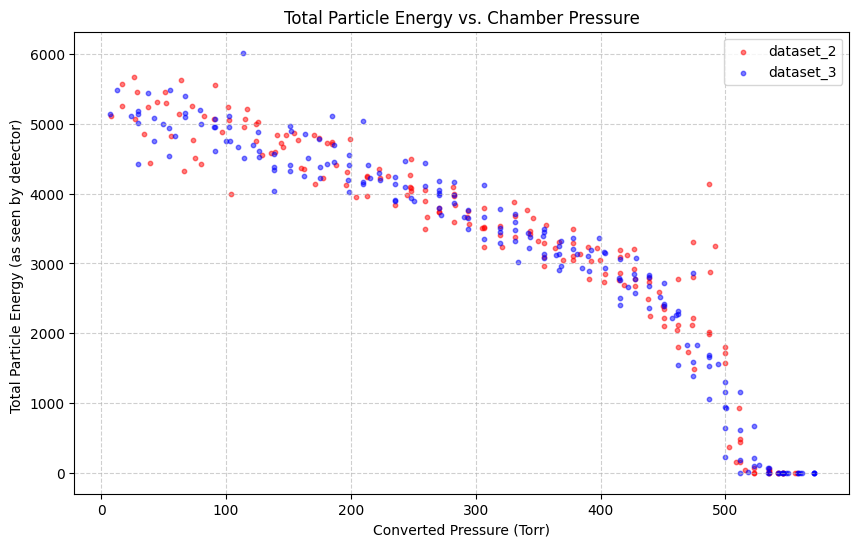

Figure 6: Total measured particle energy as a function of chamber pressure


In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(pressure_2, 
            norm_energy_2, 
            alpha=0.5, 
            s=10, 
            color='red', label='dataset_2')
plt.scatter(pressure_3, 
            norm_energy_3, 
            alpha=0.5, 
            s=10, 
            color='blue', label='dataset_3')
plt.title(r'Total Particle Energy vs. Chamber Pressure')
plt.xlabel('Converted Pressure (Torr)')
plt.ylabel('Total Particle Energy (as seen by detector) ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Figure 6: Total measured particle energy as a function of chamber pressure")

- Applying the formula to convert pressure to effective distance

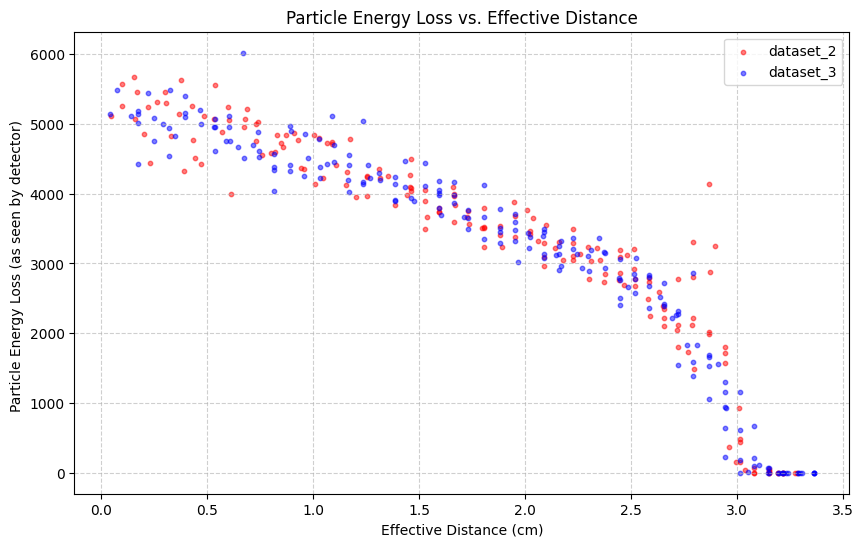

Figure 7: Same as Figure 6 but now as a function of effective distance


In [25]:
pressure_2_norm = pressure_2 / p_atm # Normalized to P_atm
eff_dist_2 = 4.5 * pressure_2_norm # In cm
pressure_3_norm = pressure_3 / p_atm # Normalized to P_atm
eff_dist_3 = 4.5 * pressure_3_norm # In cm

plt.figure(figsize=(10, 6))
plt.scatter(eff_dist_2, 
            norm_energy_2, 
            alpha=0.5, 
            s=10, 
            color='red', label='dataset_2')
plt.scatter(eff_dist_3, 
            norm_energy_3, 
            alpha=0.5, 
            s=10, 
            color='blue', label='dataset_3')
plt.title(r'Particle Energy Loss vs. Effective Distance')
plt.xlabel('Effective Distance (cm)')
plt.ylabel('Particle Energy Loss (as seen by detector) ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Figure 7: Same as Figure 6 but now as a function of effective distance")

#### 4.3 Plotting Bragg's curve

- Now for the last step, we'll need to figure out how to take the derivative of the particle energy data to plot the Bragg's curve
- Spoke to a classmate who did this lab last time + instructor and they recommended either trying a non-linear curve fit using the Bethe-Bloch model: 
$$-\frac{dE}{dx} = \frac{4\pi Z^2}{m_e v^2} \left( \frac{e^2}{4\pi\epsilon_0} \right)^2 n_e \ln \frac{2m_e v^2}{I}$$
- OR using the Savitzky-Golay filter which seemed to work in the past
- I am not confident I have all the values for the parameters: eg. average ionization potential $I$ and the non-relativistic velocity $v$ of each particle....
- I will be sticking with the savgol filter for now - it's really just doing a sliding window polynomial fit and then taking derviative of that fitted function


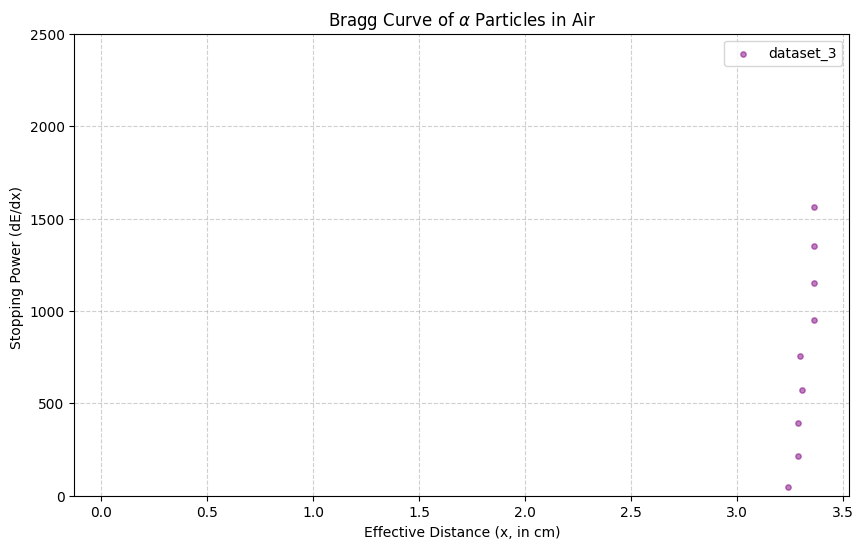

Figure 8: Bragg curve showing range-energy relationship for alpha particles in air


In [26]:
from scipy.signal import savgol_filter

# dE_dx_2 = savgol_filter(norm_energy_2, window_length=71, polyorder=3, deriv=1, delta=(eff_dist_2[1]-eff_dist_2[0]))
dE_dx_3 = savgol_filter(norm_energy_3, window_length=71, polyorder=3, deriv=1, delta=(eff_dist_3[1]-eff_dist_3[0]))

plt.figure(figsize=(10, 6))
# plt.scatter(eff_dist_2, 
#             dE_dx_2, 
#             alpha=0.5, 
#             s=10, 
#             color='red', label='dataset_2')
plt.scatter(eff_dist_3, 
            dE_dx_3, 
            alpha=0.5, 
            s=15, 
            color='purple', label='dataset_3')
plt.title(r'Bragg Curve of $\alpha$ Particles in Air')
plt.xlabel('Effective Distance (x, in cm)')
plt.ylabel('Stopping Power (dE/dx) ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(0, 2500)
plt.show()

print("Figure 8: Bragg curve showing range-energy relationship for alpha particles in air")

- This is good - the shape of this Bragg cruve closely resembles that of the curves provided in the lab manual and seen online
- The only thing I'm not sure about here is how to normalize the stopping power $dE/dx$ - the numbers on the y-axis seem a bit arbitrary since particle $V_{pp}$ is only proportional to particle energy and not equal to
- Not sure if we have enough information to determine the constant of proportionality
- Commenting out dataset 2 since it has missing data in the second half that mess with the savgol filter

#### 4.4 Determining the Bragg peak 


- We want to find the Bragg curve peak
- This point marks the distance where most particles slow down, which in turn increases the probability of collision with neighbouring particles - resulting in an large overall drop in total energy
- Another really interesting observation is that the Bragg curve drops sharply to zero after the peak - I believe this is when all particles come to a halt and total (kinetic) energy goes to 0


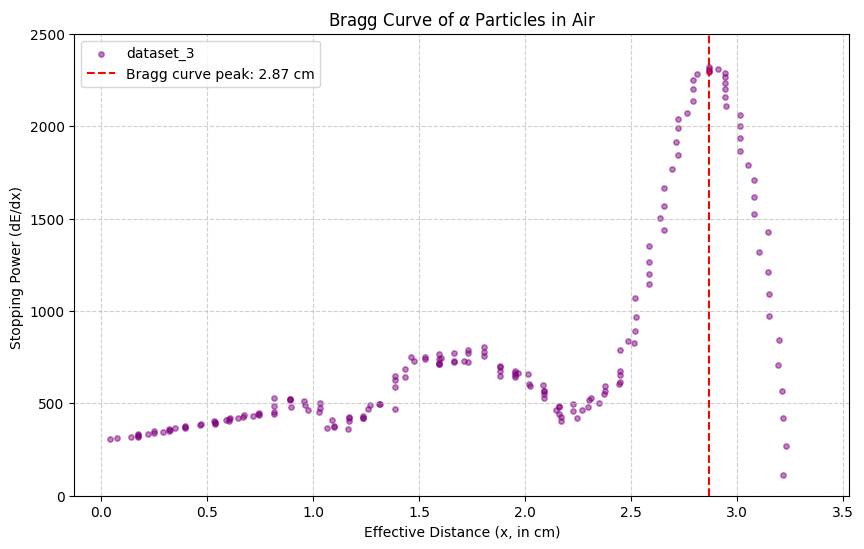

Figure 9: Vertical line marking the Bragg curve peak (occurs at 2.87 cm)


In [15]:
bragg_peak = np.argmax(dE_dx_3)
eff_dist_peak = eff_dist_3[bragg_peak]

plt.figure(figsize=(10, 6))
plt.scatter(eff_dist_3, 
            dE_dx_3, 
            alpha=0.5, 
            s=15, 
            color='purple', label='dataset_3')
plt.axvline(x=eff_dist_peak, color='red', linestyle='--', label=f'Bragg curve peak: {eff_dist_peak:.2f} cm')
plt.title(r'Bragg Curve of $\alpha$ Particles in Air')
plt.xlabel('Effective Distance (x, in cm)')
plt.ylabel('Stopping Power (dE/dx) ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(0, 2500)
plt.show()

print("Figure 9: Vertical line marking the Bragg curve peak (occurs at 2.87 cm)")